In [8]:
library(Seurat)
library(harmony)
library(spacexr)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

In [2]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')

In [3]:
obj_lamp_ST_all_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/pet_all_obj.rds')

In [4]:
obj_lamp_ST_all_raw@meta.data[,c('x_raw','y_raw')] <- obj_lamp_ST_all_raw@meta.data[,c('x','y')]

In [5]:
rotation_coor <- function(raw_df,rotation){
    r_pi <- rotation*pi/180
    r_matrix <- matrix(c(cos(r_pi),-sin(r_pi),
                         sin(r_pi),cos(r_pi)),ncol=2,nrow=2)
    r_df <- as.matrix(raw_df)%*%r_matrix
    return(r_df)
    }
obj_lamp_ST_all_raw@meta.data[,c('x','y')] <- rotation_coor(obj_lamp_ST_all_raw@meta.data[,c('x_raw','y_raw')],-80)
obj_lamp_ST_all_raw$y <- -obj_lamp_ST_all_raw$y

In [21]:
min(obj_lamp_ST_all_raw$x)

[1] 1.641733

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


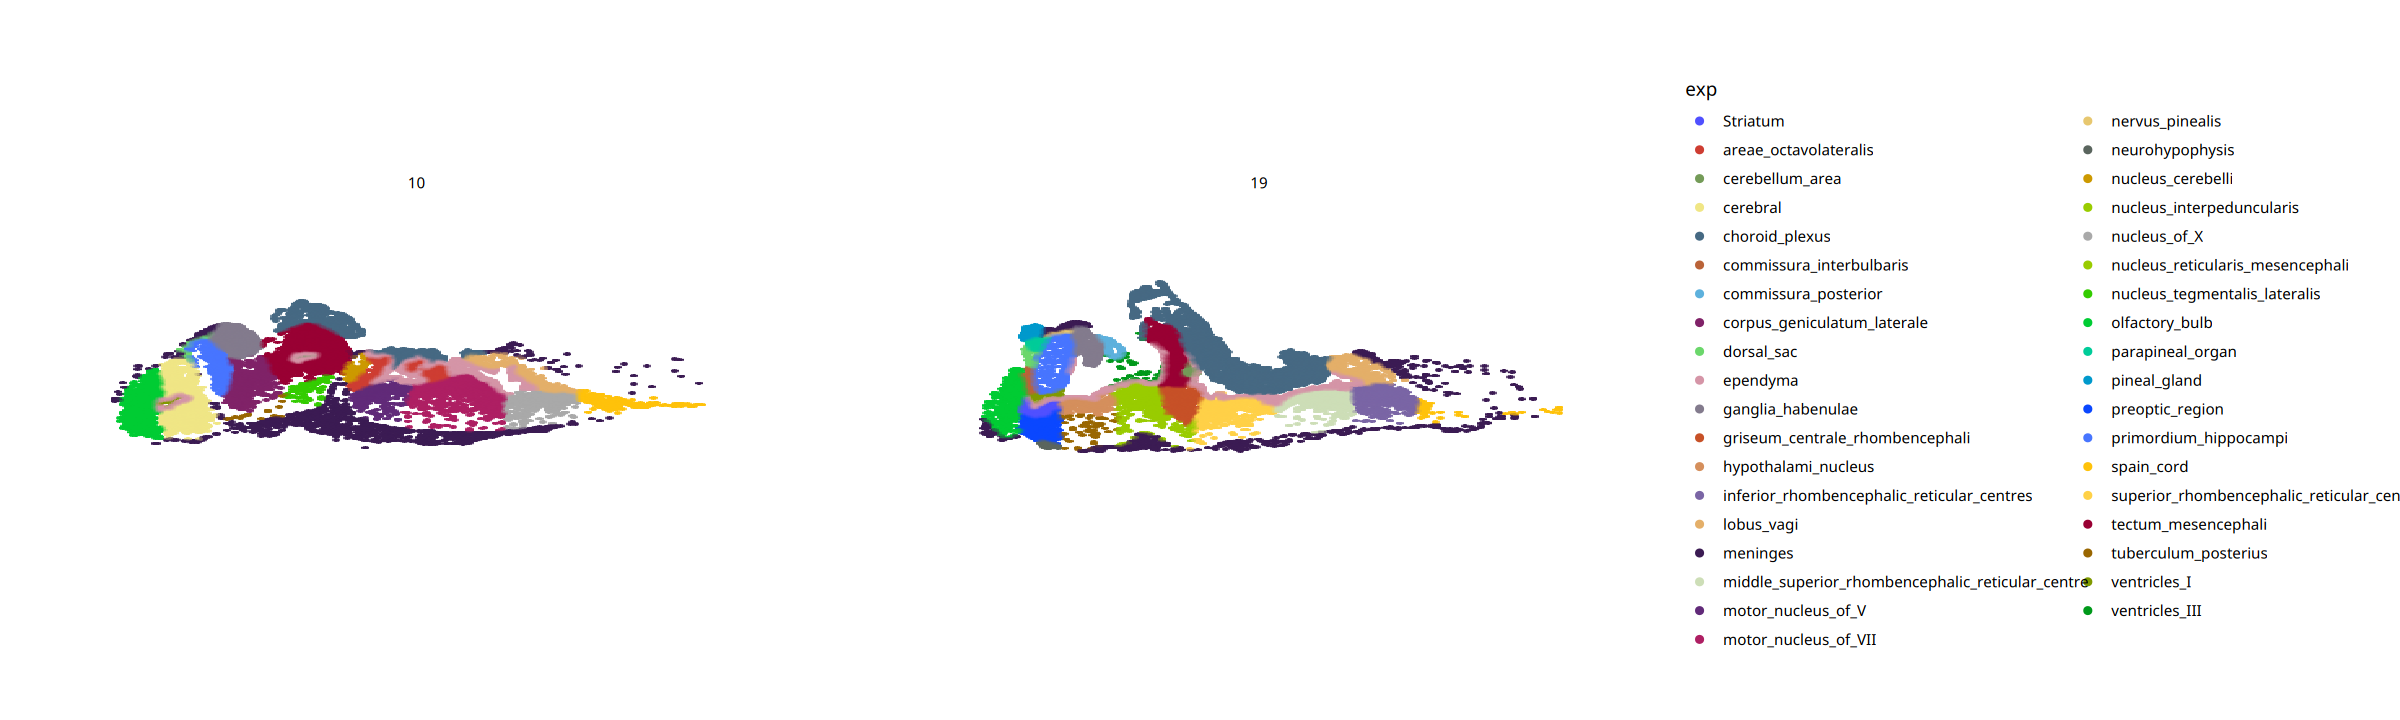

In [25]:
options(repr.plot.height=6,repr.plot.width=20)
plot_spatial_col(obj = obj_lamp_ST_all_raw@meta.data[obj_lamp_ST_all_raw@meta.data$slices%in%c(11,20),],col_name  = 'region',size = 3)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_all_raw$region)))+
facet_wrap('batch')
#plot_layout(ncol = 4)

In [ ]:
lobus_vagi

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


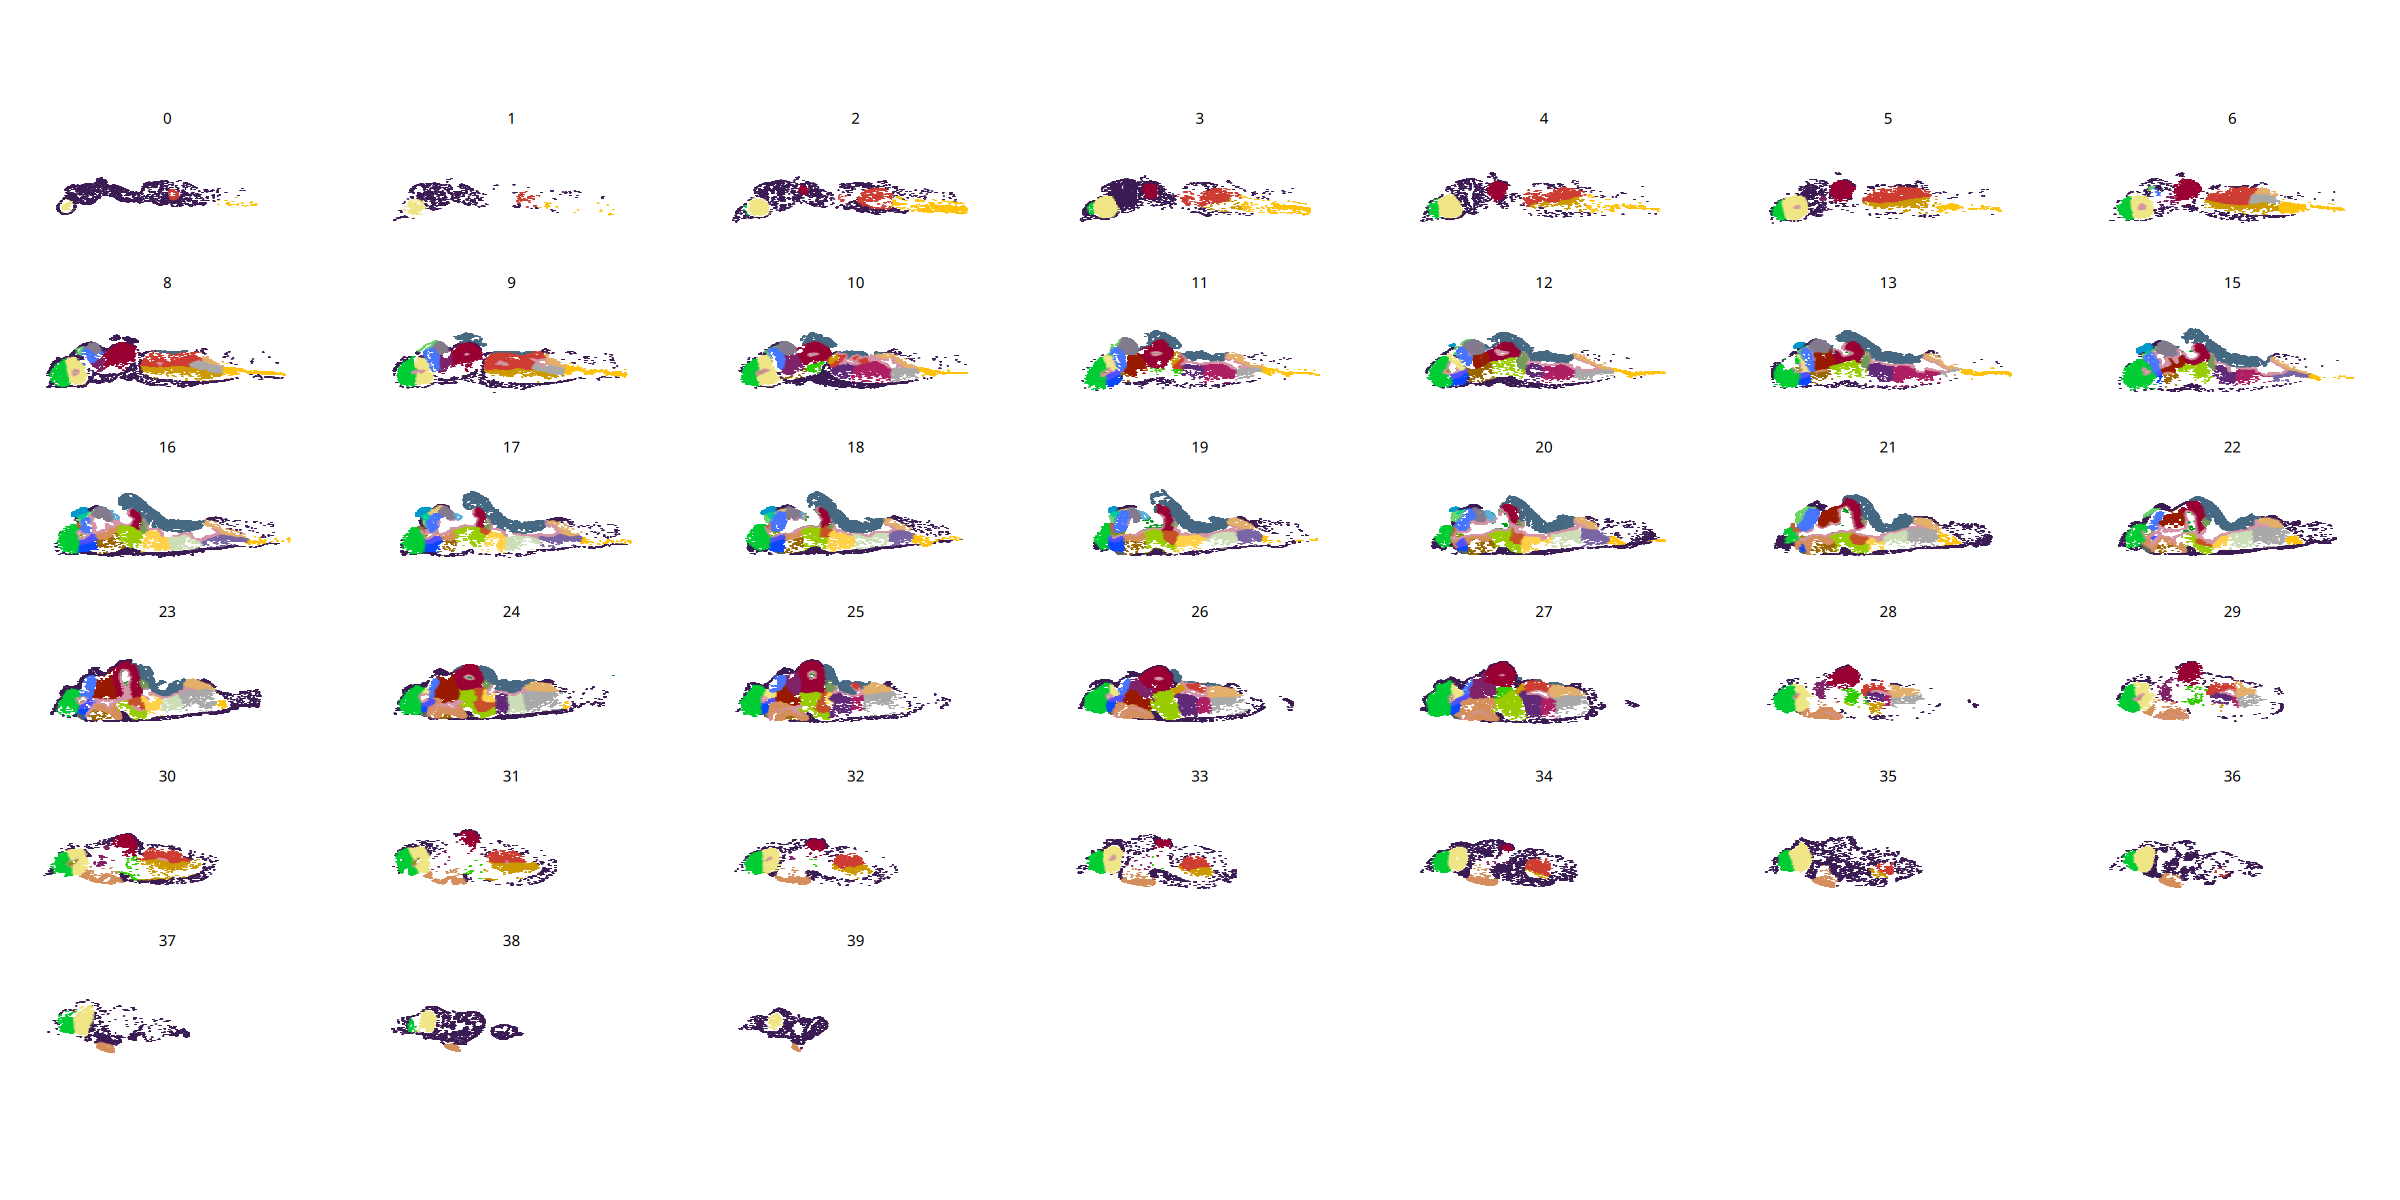

In [27]:
options(repr.plot.height=10,repr.plot.width=20)
plot_spatial_col(obj = obj_lamp_ST_all_raw@meta.data[!obj_lamp_ST_all_raw@meta.data$slices%in%c(8,15),],col_name  = 'region',size = 3)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_all_raw$region)))+
facet_wrap('batch')+
NoLegend()
#plot_layout(ncol = 4)

In [6]:
obj_lamp_ST_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/lamp_cortex.rds')
obj_lamp_ST_raw@meta.data[,c('x_raw','y_raw')] <- obj_lamp_ST_raw@meta.data[,c('x','y')]

In [7]:
rotation_coor <- function(raw_df,rotation){
    r_pi <- rotation*pi/180
    r_matrix <- matrix(c(cos(r_pi),-sin(r_pi),
                         sin(r_pi),cos(r_pi)),ncol=2,nrow=2)
    r_df <- as.matrix(raw_df)%*%r_matrix
    return(r_df)
    }
obj_lamp_ST_raw@meta.data[,c('x','y')] <- rotation_coor(obj_lamp_ST_raw@meta.data[,c('x_raw','y_raw')],-80)
obj_lamp_ST_raw$y <- -obj_lamp_ST_raw$y

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


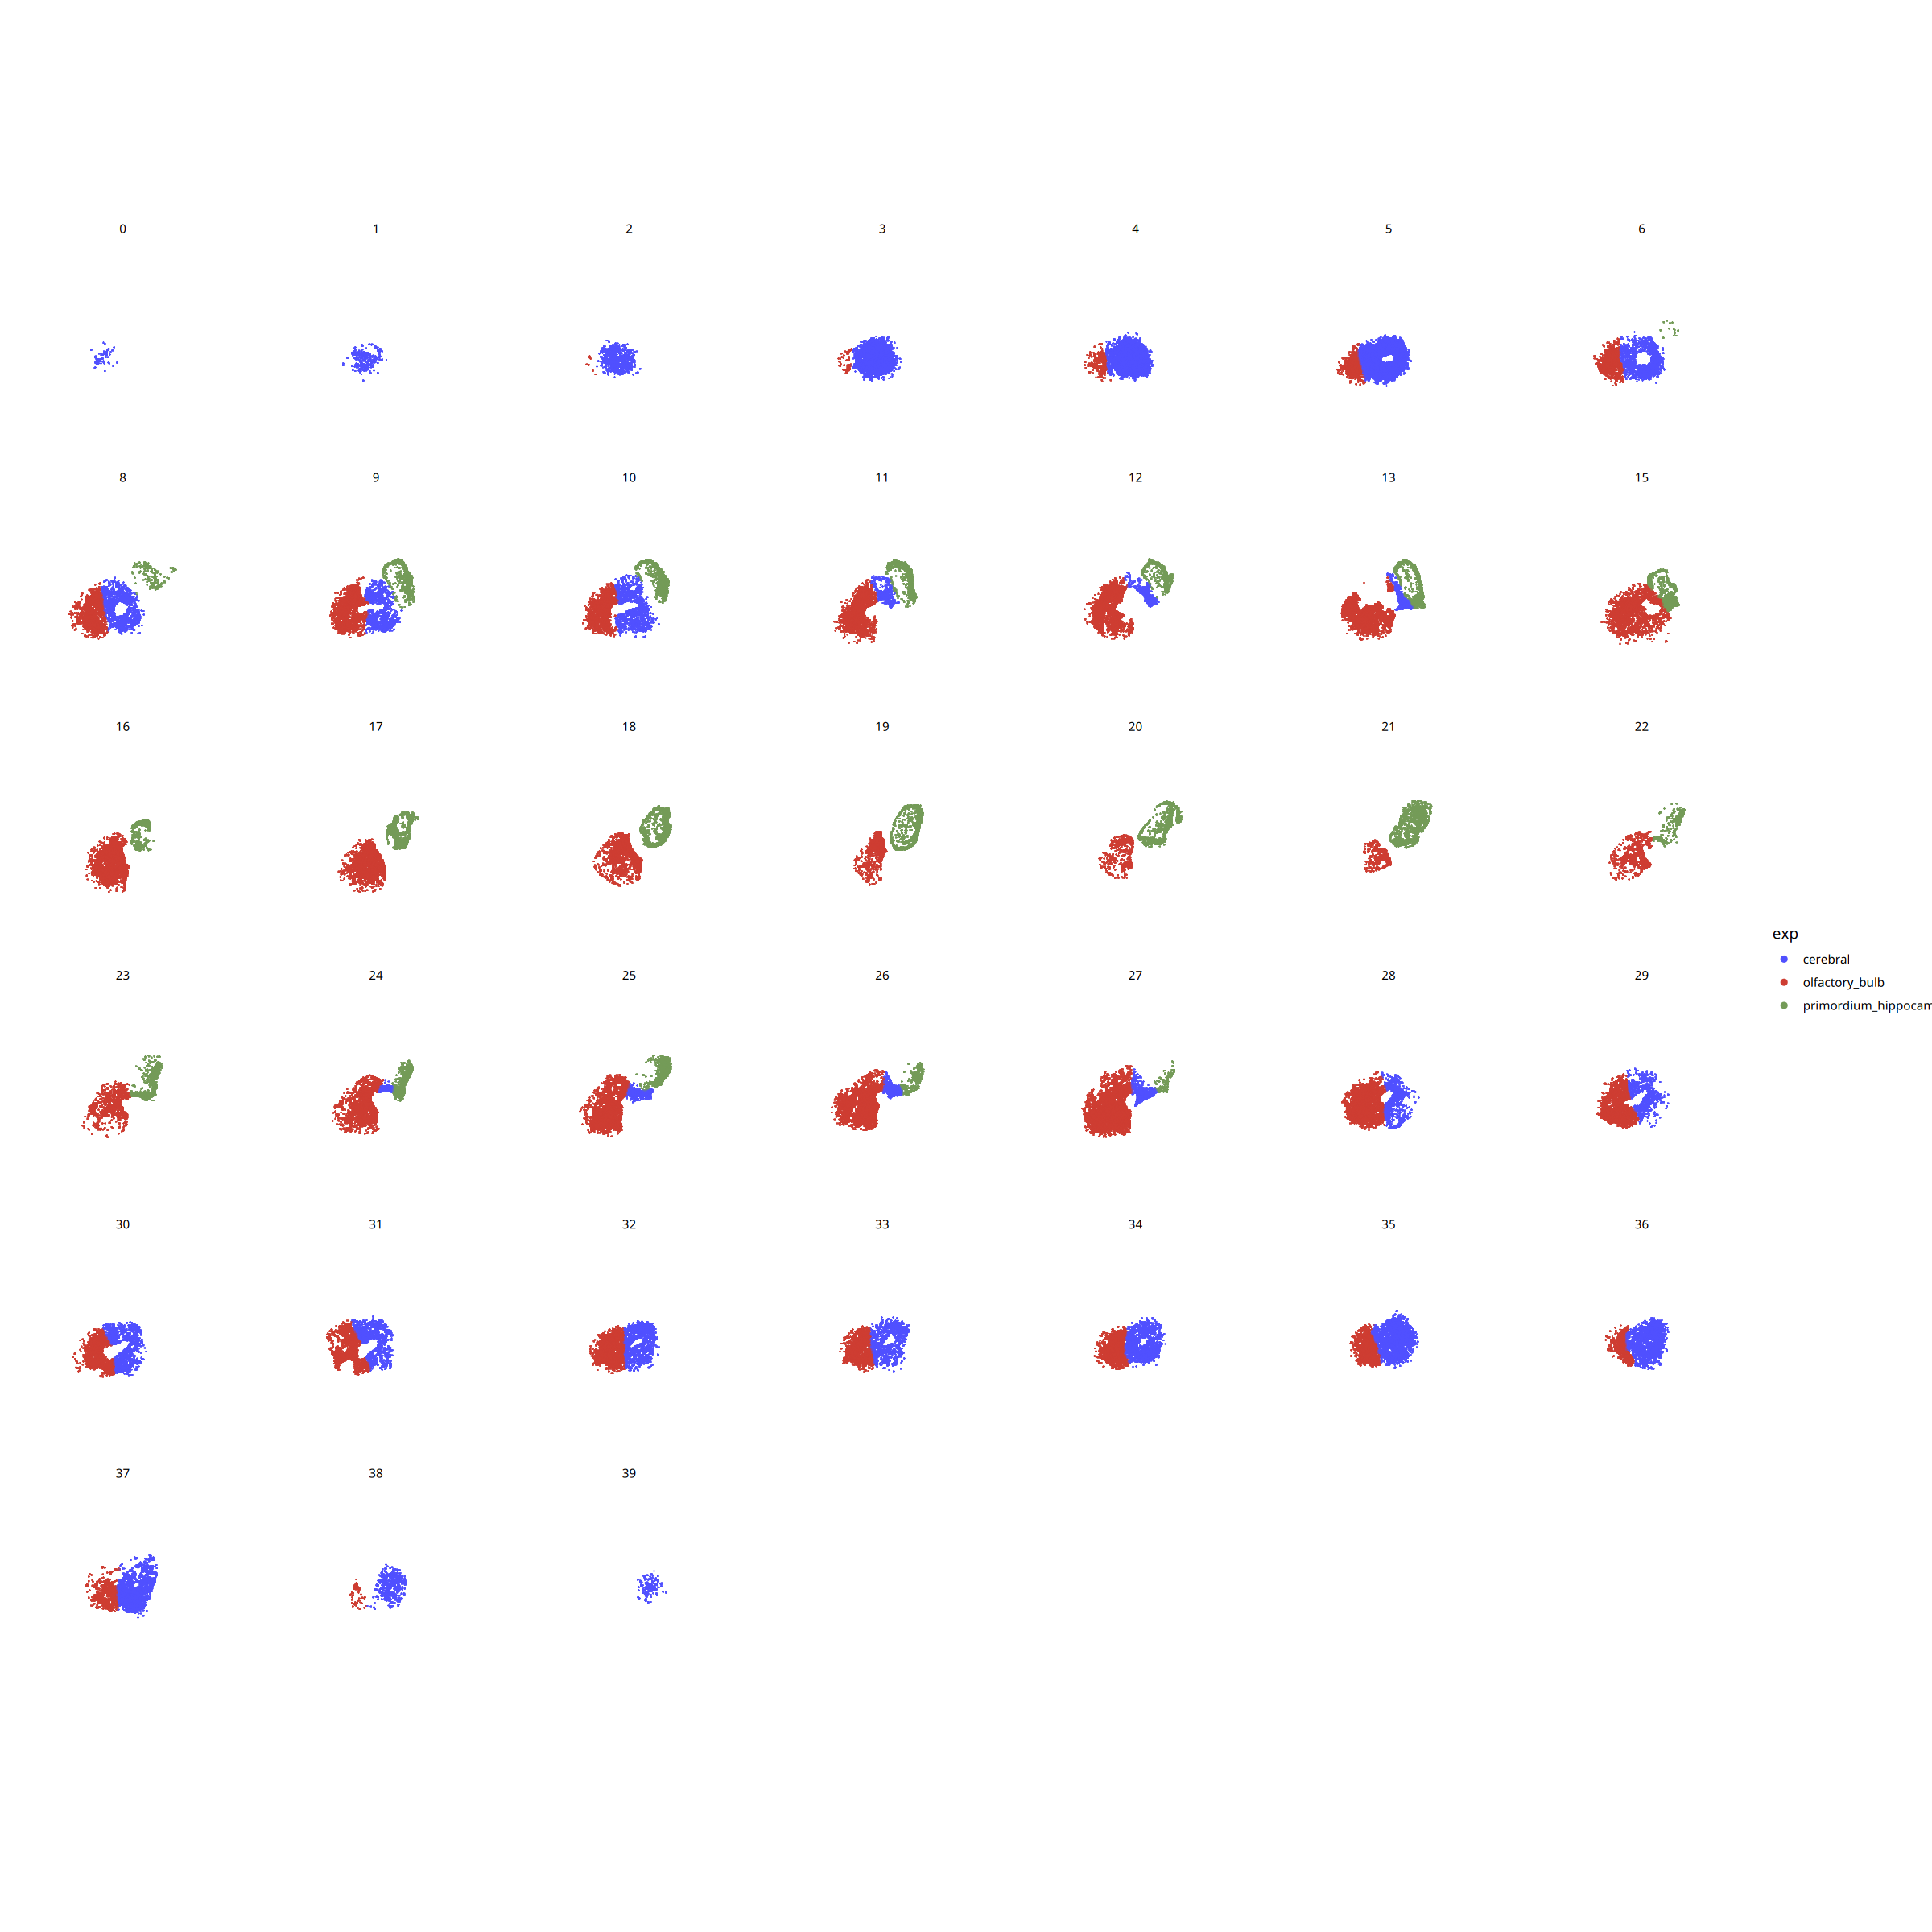

In [30]:
options(repr.plot.height=20,repr.plot.width=20)
plot_spatial_col(obj = obj_lamp_ST_raw@meta.data[!obj_lamp_ST_raw@meta.data$slices%in%c(8,15),],col_name  = 'region',size = 3)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_raw$region)))+
facet_wrap('batch')
#plot_layout(ncol = 4)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


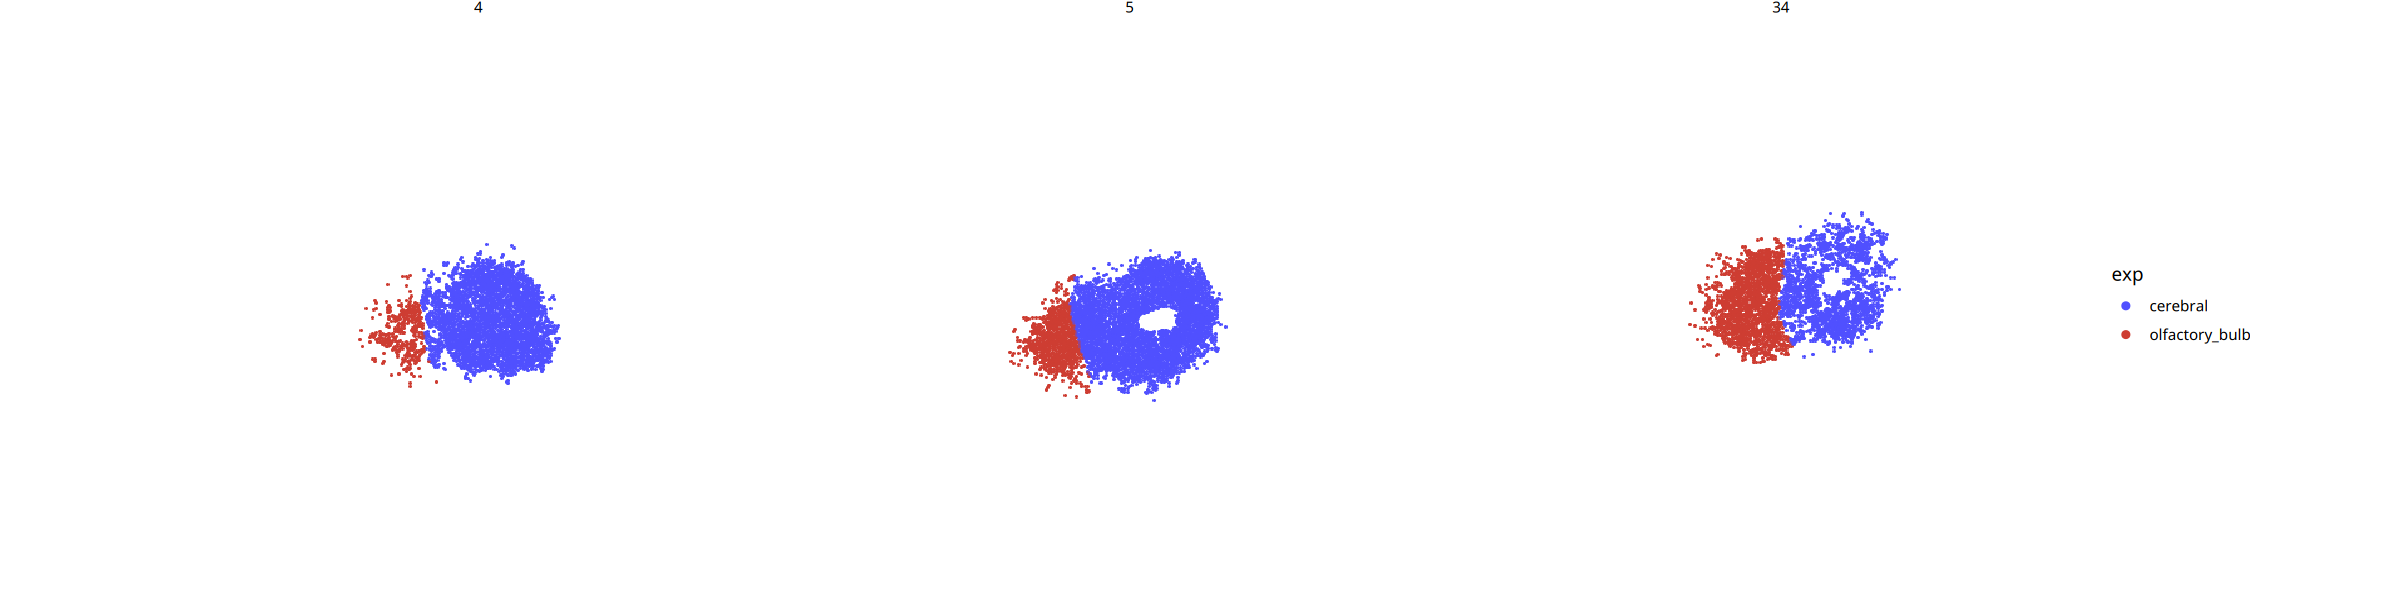

In [86]:
options(repr.plot.height=5,repr.plot.width=20)
plot_spatial_col(obj = obj_lamp_ST_raw@meta.data[obj_lamp_ST_raw@meta.data$batch%in%c(4,5,34),],col_name  = 'region',size = 2)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_raw$region)))+
facet_wrap('batch',ncol=4)
#plot_layout(ncol = 4)

In [9]:
source('../R_function/calculate_function.R')

In [20]:
obj_lamp_ST_cluster <- obj_lamp_ST_raw[,obj_lamp_ST_raw@meta.data$batch%in%c(4,5,34)&obj_lamp_ST_raw$region%in%c('cerebral','olfactory_bulb')]
obj_lamp_ST_cluster$group <- paste0('la_',round(obj_lamp_ST_cluster$x*200/25,0),'_',round(obj_lamp_ST_cluster$y*200/25,0),'_',obj_lamp_ST_cluster$batch)

region <- aggregate(obj_lamp_ST_cluster$region,by=list("group"=obj_lamp_ST_cluster$group),FUN=function(x){names(sort(table(x),decreasing = T))[1]})
rownames(region) <- region$group

obj_lamp_ST_cluster <- CreateSeuratObject(matrix_groupby(obj_lamp_ST_cluster[['RNA']]@counts,group.by = obj_lamp_ST_cluster$group,type = 'col',cal = 'sum'))
obj_lamp_ST_cluster$x <- as.numeric(sapply(colnames(obj_lamp_ST_cluster),function(x){return(strsplit(x,'_')[[1]][2])}))
obj_lamp_ST_cluster$y <- as.numeric(sapply(colnames(obj_lamp_ST_cluster),function(x){return(strsplit(x,'_')[[1]][3])}))
obj_lamp_ST_cluster$sample <- paste0('lamp_',as.numeric(sapply(colnames(obj_lamp_ST_cluster),function(x){return(strsplit(x,'_')[[1]][4])})))
obj_lamp_ST_cluster$region <- region[rownames(obj_lamp_ST_cluster@meta.data),2]

In [21]:
obj_lamp_ST_cluster@active.assay <- 'RNA'
obj_lamp_ST_cluster <- NormalizeData(obj_lamp_ST_cluster)
obj_lamp_ST_cluster <- FindVariableFeatures(obj_lamp_ST_cluster,nfeatures = 3000)
obj_lamp_ST_cluster <- ScaleData(obj_lamp_ST_cluster,verbose=FALSE)
obj_lamp_ST_cluster <- RunPCA(obj_lamp_ST_cluster,npcs=30,verbose=FALSE)
obj_lamp_ST_cluster <- RunHarmony(obj_lamp_ST_cluster,verbose = F,reduction.use = 'pca',group.by.vars = 'sample')

In [22]:
obj_lamp_ST_cluster <- RunUMAP(obj_lamp_ST_cluster,dims=1:15,reduction = 'harmony',verbose = F)

In [23]:
obj_lamp_ST_cluster <- FindNeighbors(obj_lamp_ST_cluster,reduction = 'harmony',dims=1:15)
obj_lamp_ST_cluster <- FindClusters(obj_lamp_ST_cluster,resolution = 0.5)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2903
Number of edges: 111748

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7930
Number of communities: 5
Elapsed time: 0 seconds


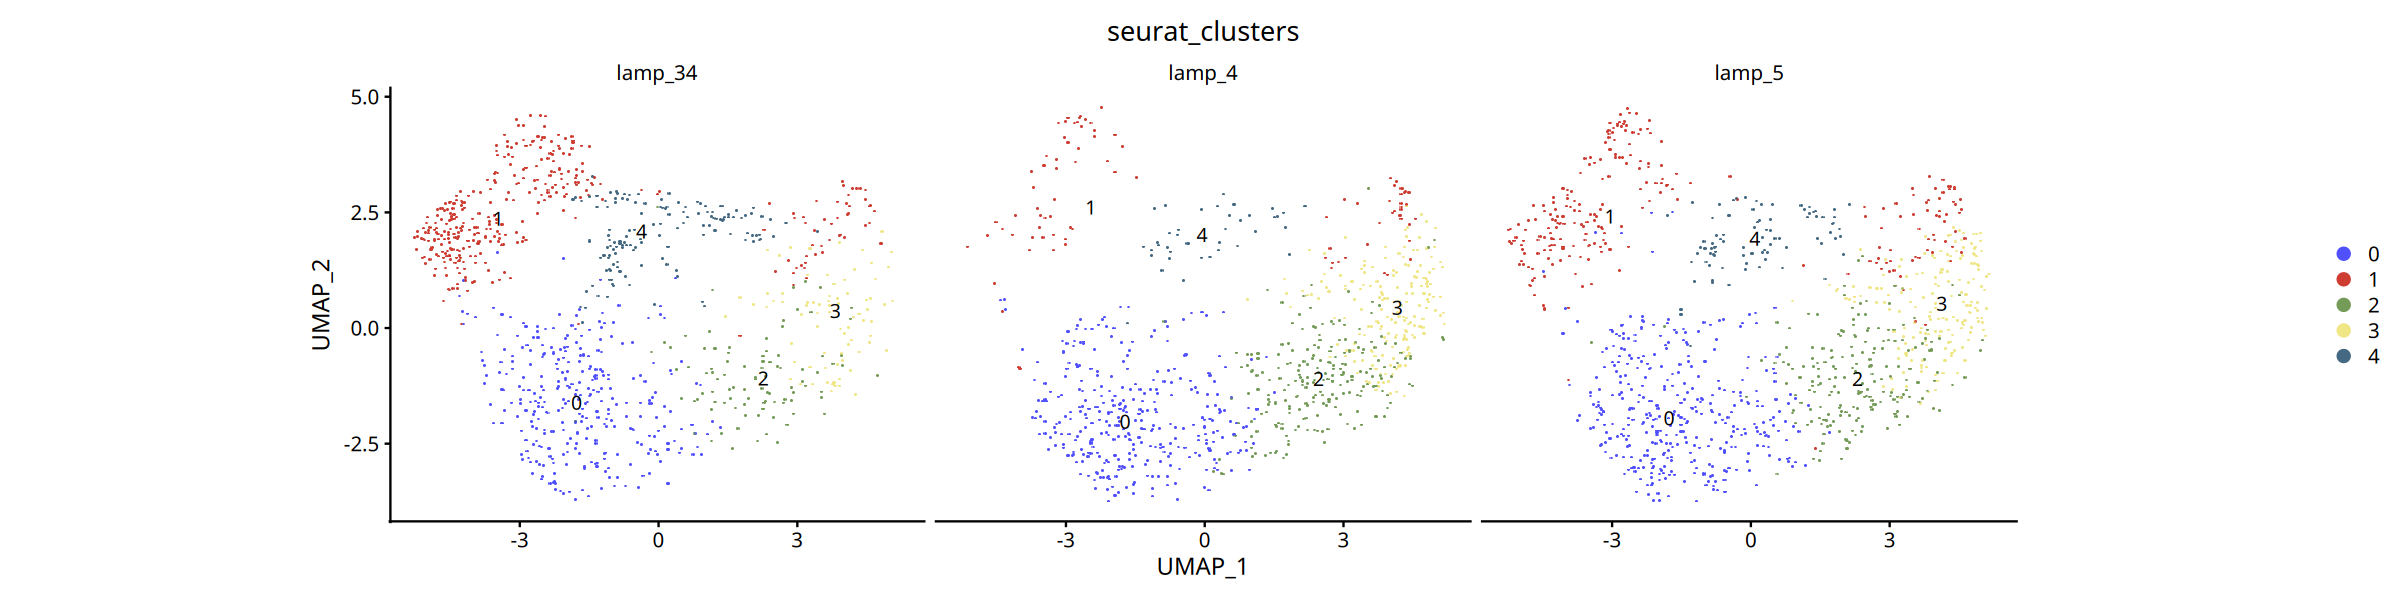

In [24]:
p <- DimPlot(obj_lamp_ST_cluster,reduction = 'umap',split.by = 'sample',pt.size = 2,raster=T,group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_cluster$seurat_clusters)))+
coord_fixed()
p

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


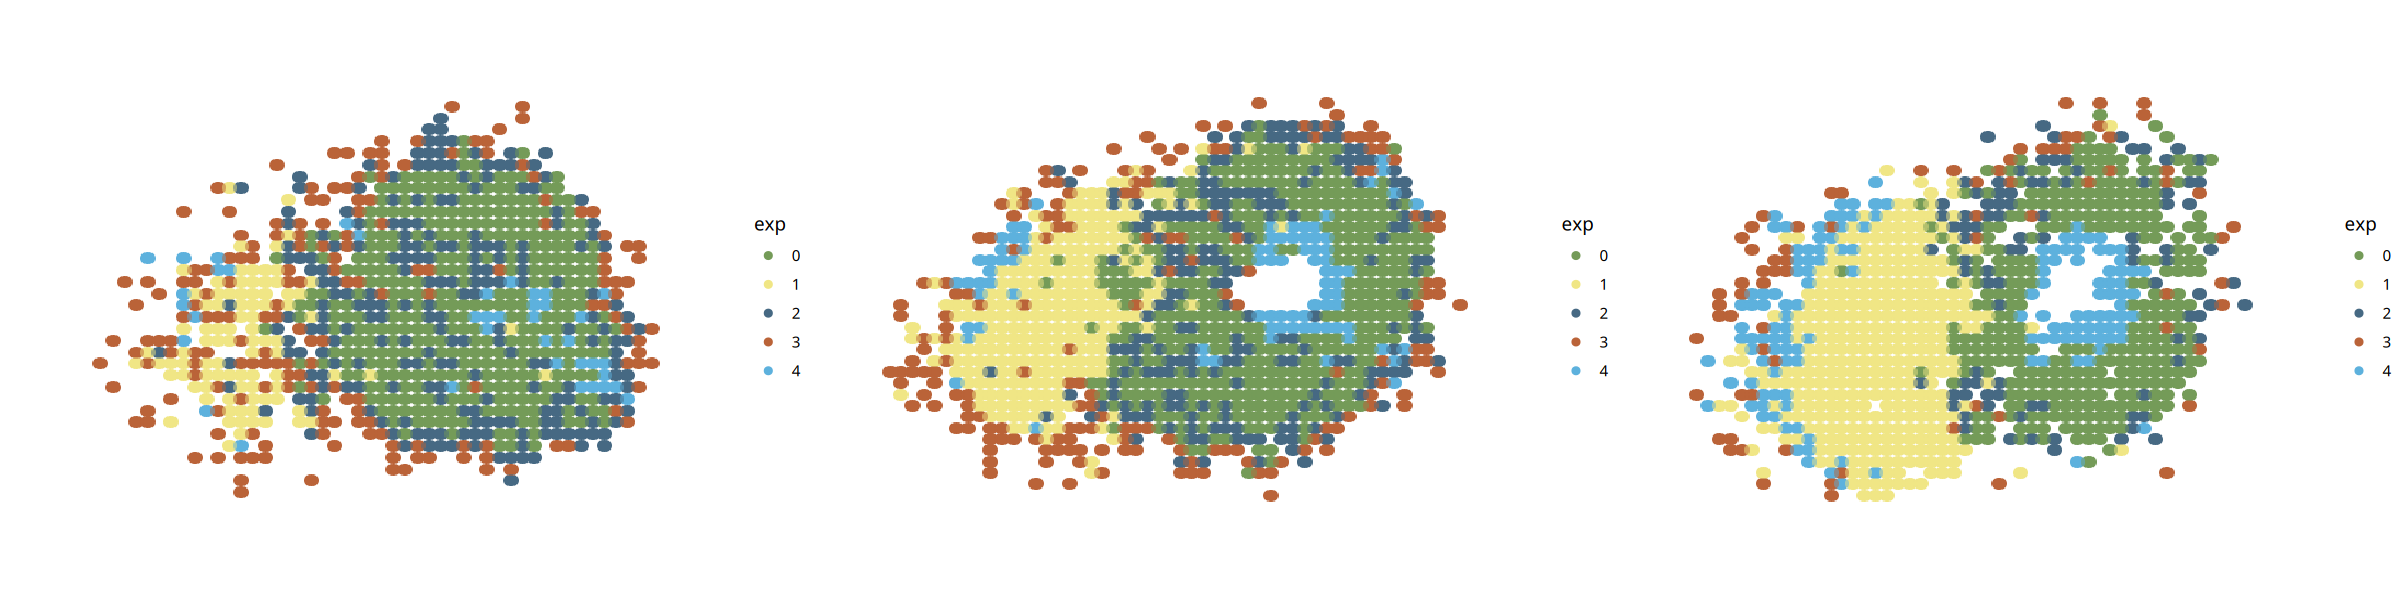

In [26]:
p1 <- plot_spatial_col(obj_lamp_ST_cluster@meta.data[obj_lamp_ST_cluster$sample=='lamp_4',],   col_name = 'seurat_clusters',smooth = F, size = 6)+scale_color_manual(values = pal_igv()(50)[3:40],breaks = sort(unique(obj_lamp_ST_cluster$seurat_clusters)))
p2 <- plot_spatial_col(obj_lamp_ST_cluster@meta.data[obj_lamp_ST_cluster$sample=='lamp_5',],  col_name = 'seurat_clusters',smooth = F, size = 6)+scale_color_manual(values = pal_igv()(50)[3:40],breaks = sort(unique(obj_lamp_ST_cluster$seurat_clusters)))
p3 <- plot_spatial_col(obj_lamp_ST_cluster@meta.data[obj_lamp_ST_cluster$sample=='lamp_34',],  col_name = 'seurat_clusters',smooth = F, size = 6)+scale_color_manual(values = pal_igv()(50)[3:40],breaks = sort(unique(obj_lamp_ST_cluster$seurat_clusters)))
p1+p2+p3+plot_layout(ncol = 3)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


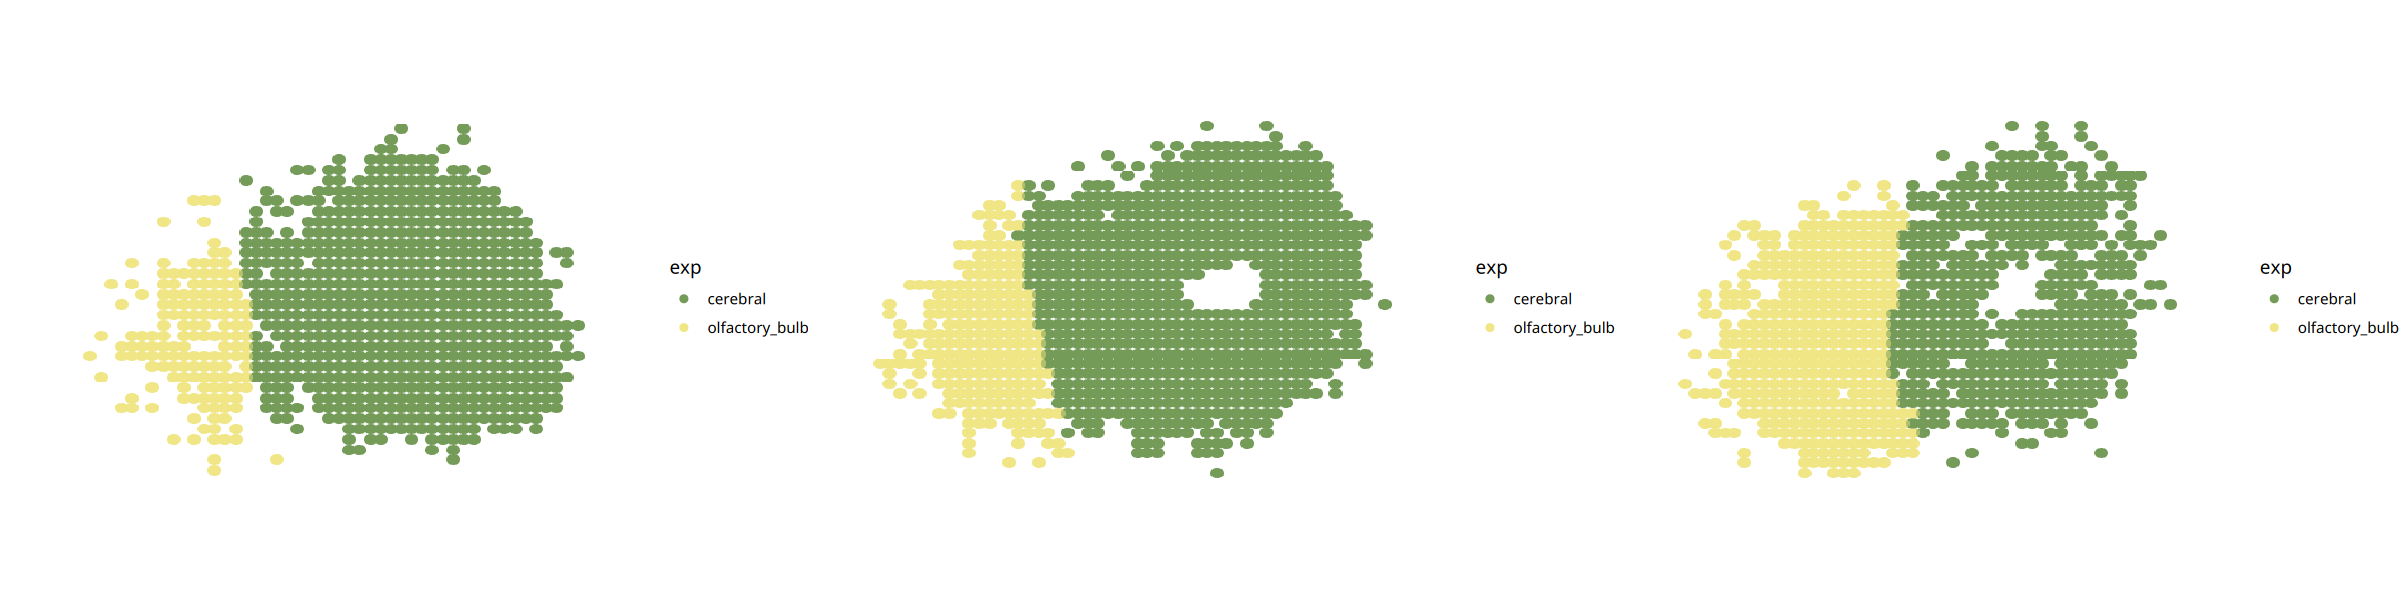

In [27]:
p1 <- plot_spatial_col(obj_lamp_ST_cluster@meta.data[obj_lamp_ST_cluster$sample=='lamp_4',],   col_name = 'region',smooth = F, size = 6)+scale_color_manual(values = pal_igv()(50)[3:40],breaks = sort(unique(obj_lamp_ST_cluster$region)))
p2 <- plot_spatial_col(obj_lamp_ST_cluster@meta.data[obj_lamp_ST_cluster$sample=='lamp_5',],  col_name = 'region',smooth = F, size = 6)+scale_color_manual(values = pal_igv()(50)[3:40],breaks = sort(unique(obj_lamp_ST_cluster$region)))
p3 <- plot_spatial_col(obj_lamp_ST_cluster@meta.data[obj_lamp_ST_cluster$sample=='lamp_34',],  col_name = 'region',smooth = F, size = 6)+scale_color_manual(values = pal_igv()(50)[3:40],breaks = sort(unique(obj_lamp_ST_cluster$region)))
p1+p2+p3+plot_layout(ncol = 3)

In [28]:
saveRDS(obj_lamp_ST_cluster,'Analysis/Region_defined/Gene_lamp_TEOF.rds')

In [3]:
obj_lamp_ST_cluster <- readRDS('Analysis/Region_defined/Gene_lamp_TEOF.rds')

In [4]:
obj_lamp_ST_cluster_pallium <- obj_lamp_ST_cluster[,obj_lamp_ST_cluster$seurat_clusters%in%c(0,2,4)&obj_lamp_ST_cluster$region=='cerebral']

In [ ]:
obj_lamp_ST_cluster_pallium <- readRDS('Analysis/Region_defined/Gene_lamp.rds')

In [5]:
obj_lamp_ST_cluster_pallium@active.assay <- 'RNA'
obj_lamp_ST_cluster_pallium <- NormalizeData(obj_lamp_ST_cluster_pallium)
obj_lamp_ST_cluster_pallium <- FindVariableFeatures(obj_lamp_ST_cluster_pallium,nfeatures = 5000)
obj_lamp_ST_cluster_pallium <- ScaleData(obj_lamp_ST_cluster_pallium,verbose=FALSE)
obj_lamp_ST_cluster_pallium <- RunPCA(obj_lamp_ST_cluster_pallium,npcs=30,verbose=FALSE)
obj_lamp_ST_cluster_pallium <- RunHarmony(obj_lamp_ST_cluster_pallium,verbose = F,reduction.use = 'pca',group.by.vars = 'sample')
obj_lamp_ST_cluster_pallium <- RunUMAP(obj_lamp_ST_cluster_pallium,dims=1:15,reduction = 'harmony',verbose = F)
obj_lamp_ST_cluster_pallium <- FindNeighbors(obj_lamp_ST_cluster_pallium,reduction = 'harmony',dims=1:15)
obj_lamp_ST_cluster_pallium <- FindClusters(obj_lamp_ST_cluster_pallium,resolution = 0.5)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1669
Number of edges: 66802

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7428
Number of communities: 4
Elapsed time: 0 seconds


In [ ]:
[c(4,18,14,15)]

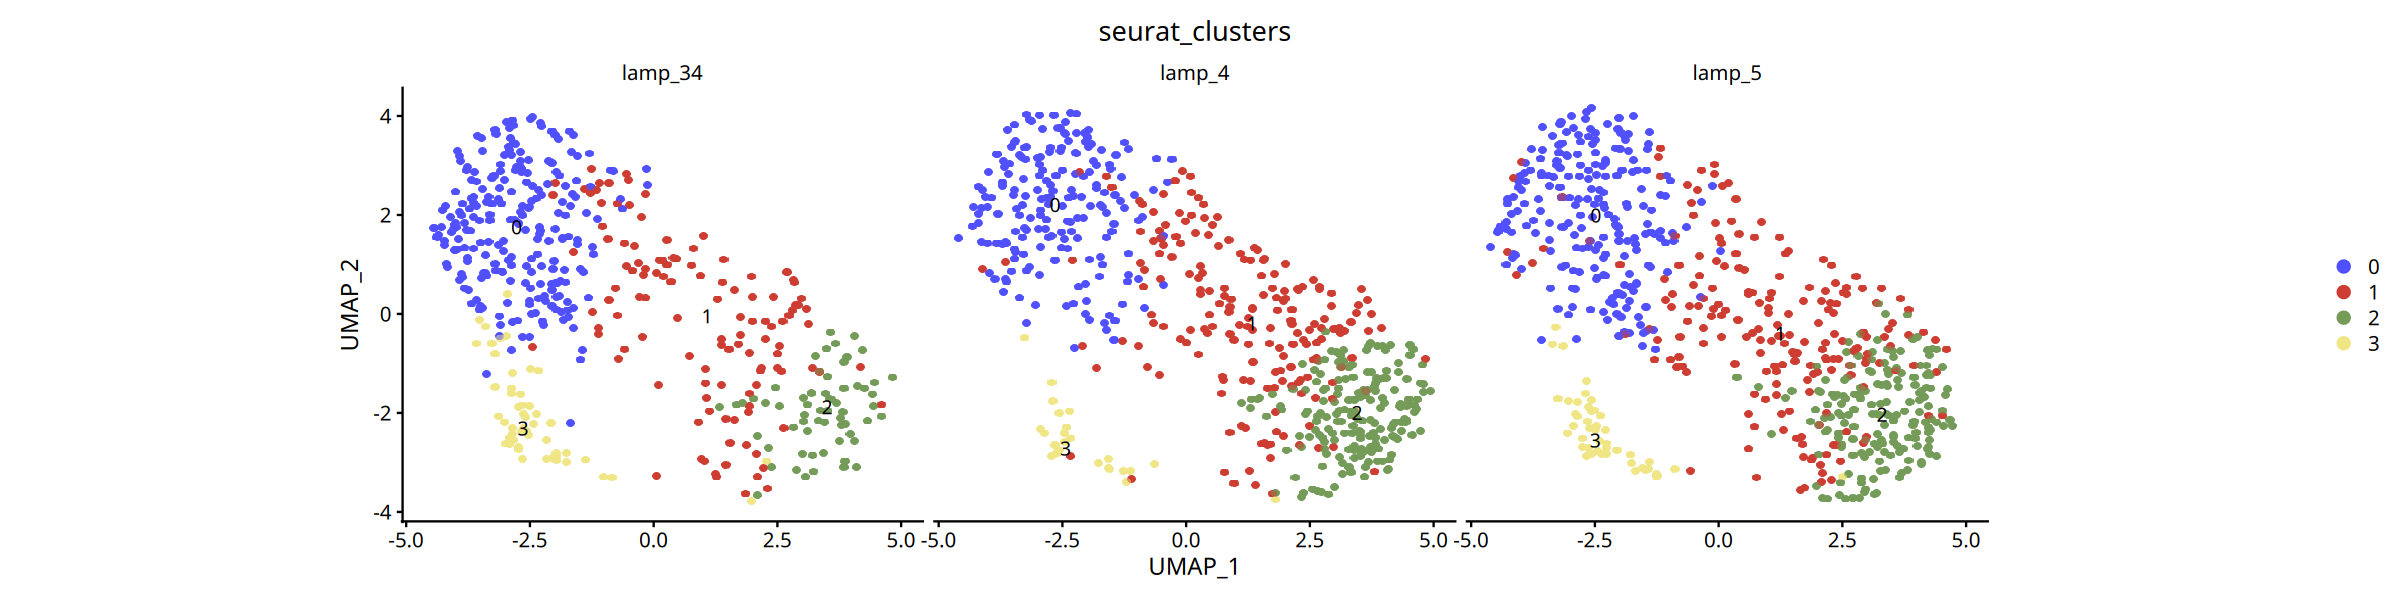

In [6]:
options(repr.plot.height=5,repr.plot.width=20)
p <- DimPlot(obj_lamp_ST_cluster_pallium,reduction = 'umap',split.by = 'sample',pt.size = 5,raster=T,group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))+
coord_fixed()
p

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


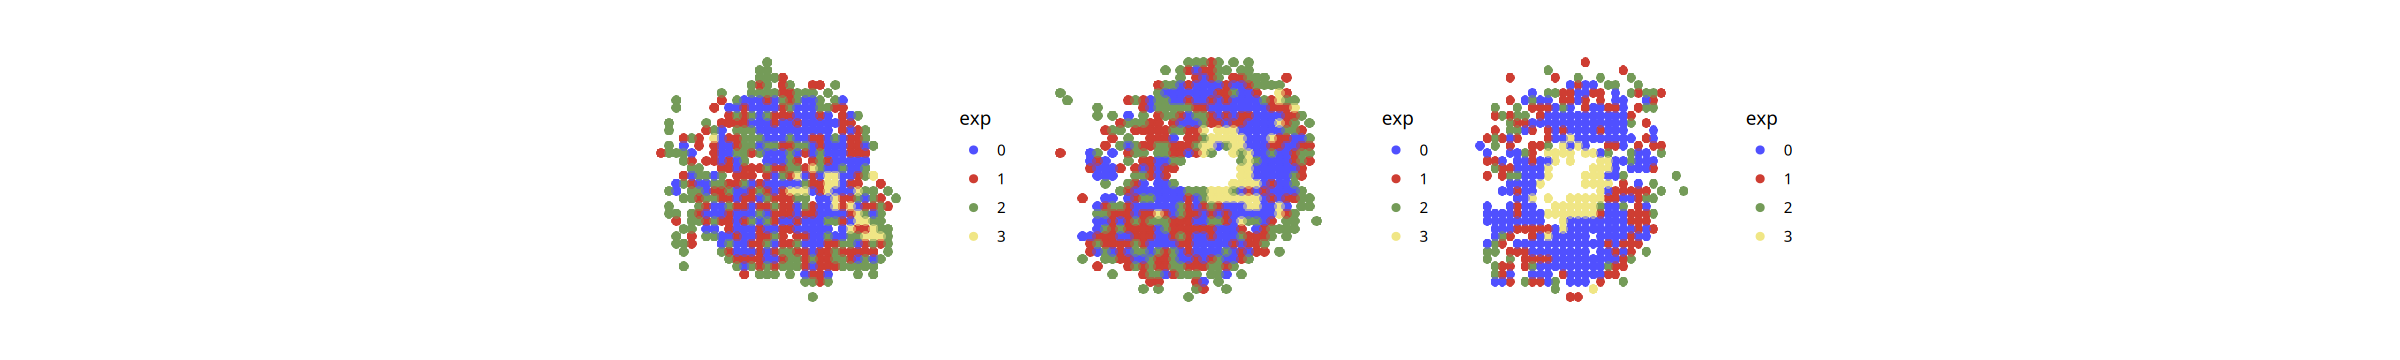

In [7]:
options(repr.plot.height=3,repr.plot.width=20)
p1 <- plot_spatial_col(obj_lamp_ST_cluster_pallium@meta.data[obj_lamp_ST_cluster_pallium$sample=='lamp_4',],   col_name = 'seurat_clusters',smooth = F, size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))
p2 <- plot_spatial_col(obj_lamp_ST_cluster_pallium@meta.data[obj_lamp_ST_cluster_pallium$sample=='lamp_5',],  col_name = 'seurat_clusters',smooth = F, size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))
p3 <- plot_spatial_col(obj_lamp_ST_cluster_pallium@meta.data[obj_lamp_ST_cluster_pallium$sample=='lamp_34',],  col_name = 'seurat_clusters',smooth = F, size = 8)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))
p1+p2+p3+plot_layout(ncol = 3)

In [10]:
obj_lamp_ST_cluster_pallium <- readRDS('Analysis/Region_defined/Gene_lamp.rds')

pdf 
  2

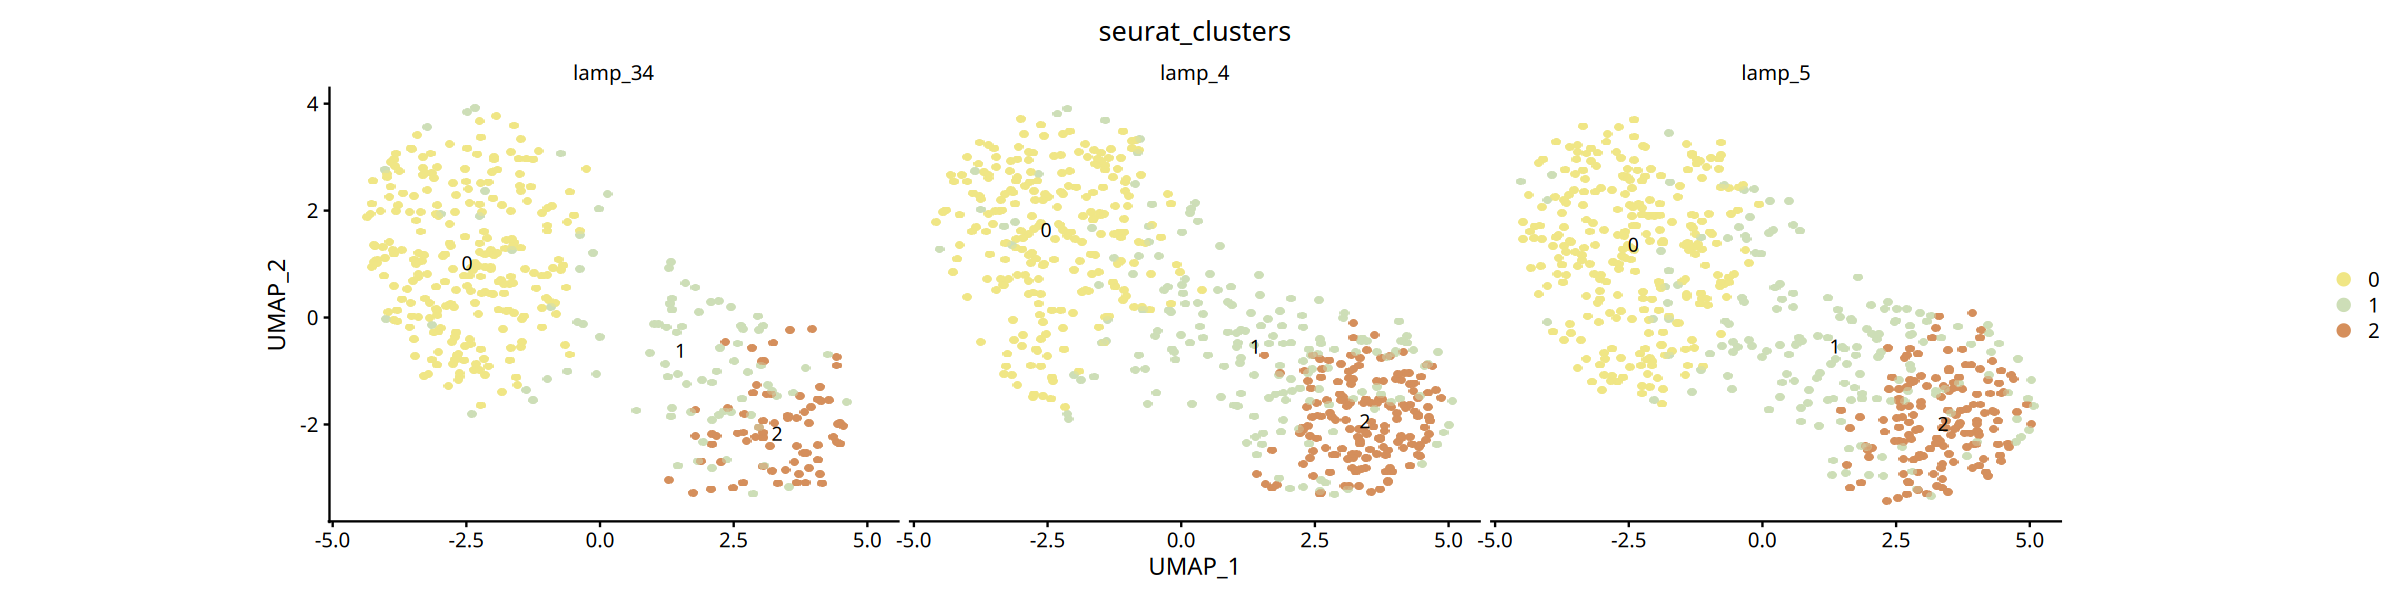

In [40]:
options(repr.plot.height=5,repr.plot.width=20)
p <- DimPlot(obj_lamp_ST_cluster_pallium,reduction = 'umap',split.by = 'sample',pt.size = 5,raster=T,group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15)],breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Lamp_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

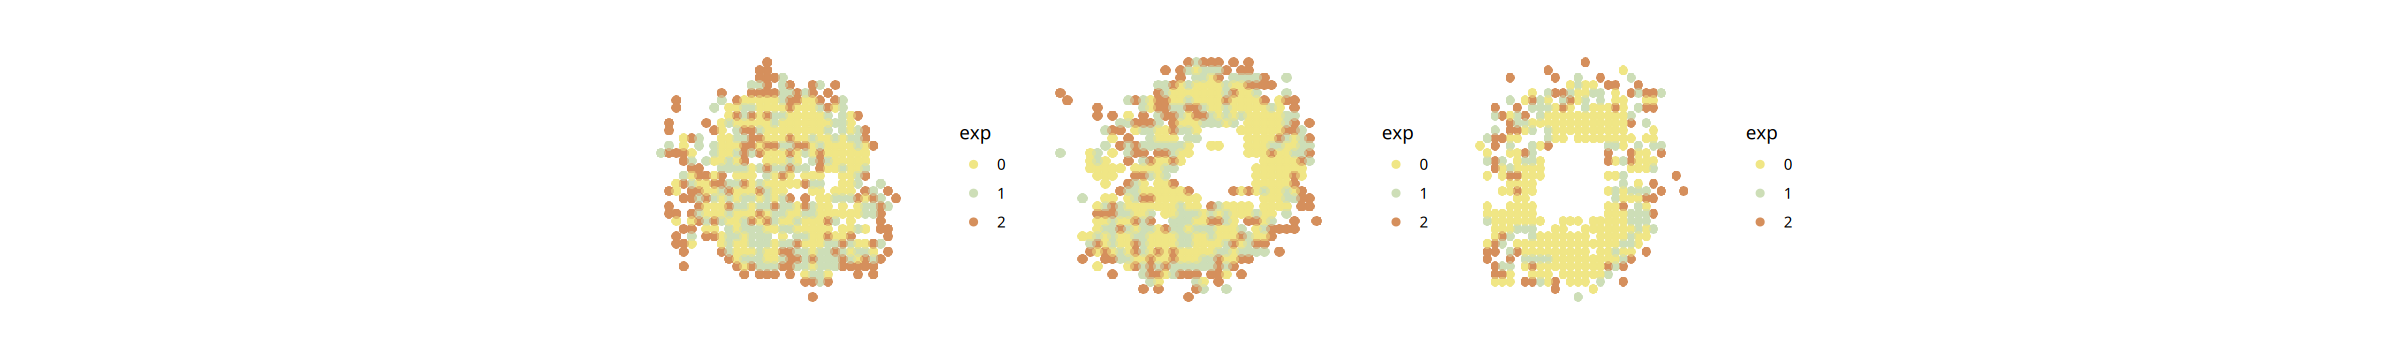

In [12]:
options(repr.plot.height=3,repr.plot.width=20)
p1 <- plot_spatial_col(obj_lamp_ST_cluster_pallium@meta.data[obj_lamp_ST_cluster_pallium$sample=='lamp_4',],   col_name = 'seurat_clusters',smooth = F, size = 8)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15)],breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))
p2 <- plot_spatial_col(obj_lamp_ST_cluster_pallium@meta.data[obj_lamp_ST_cluster_pallium$sample=='lamp_5',],  col_name = 'seurat_clusters',smooth = F, size = 8)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15)],breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))
p3 <- plot_spatial_col(obj_lamp_ST_cluster_pallium@meta.data[obj_lamp_ST_cluster_pallium$sample=='lamp_34',],  col_name = 'seurat_clusters',smooth = F, size = 8)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15)],breaks = sort(unique(obj_lamp_ST_cluster_pallium$seurat_clusters)))
p1+p2+p3+plot_layout(ncol = 3)
pdf('Plot/Region_cluster/Lamp_spatial_cluster.pdf',height = 3,width = 20)
p1+p2+p3+plot_layout(ncol = 3)
dev.off()

In [42]:
saveRDS(obj_lamp_ST_cluster_pallium,'Analysis/Region_defined/Gene_lamp.rds')

In [117]:
saveRDS( obj_lamp_ST_cluster_pallium@reductions$harmony,'Analysis/Region_defined/Reduction_lamp.rds')